# 🏨 Hotel Booking Dataset - Data Cleaning

## 📋 Project Overview

This notebook focuses on cleaning and preparing the Hotel Booking dataset for further analysis.

The objective of this stage is to identify and address data quality issues that may affect the reliability of future analysis. The dataset is examined for missing values, duplicate records, incorrect data types, anomalies, and extreme outliers.

The cleaning process aims to ensure that the final dataset is accurate, consistent, and suitable for exploratory analysis and SQL-based investigation.

## 🧹 Cleaning Tasks

The following steps are performed throughout this notebook:

- Initial dataset inspection
- Missing value analysis and treatment
- Data type validation
- Duplicate record investigation
- Anomaly detection
- Outlier analysis
- Final dataset validation

## 📊 Dataset Information

The dataset contains hotel reservation records from Resort Hotels and City Hotels between 2015 and 2017.

Initial dataset size:
- Rows: 119,390
- Columns: 32

## 🎯 Cleaning Objectives

The main goals of this data cleaning process are:

- Improve data quality
- Handle missing values
- Investigate duplicate observations
- Identify invalid reservations
- Detect and evaluate outliers
- Prepare a reliable dataset for future analysisRows: 119,390
- Columns: 32

## 📚 Import Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv(r"C:\Users\Kompiuteris\Downloads\hotel_bookings.csv")

df = df.replace(["NULL", "NA"], None)

df.to_csv(r"C:\Users\Kompiuteris\Downloads\hotel_bookings.csv", index=False)

## 📋 Initial Data Inspection

Before performing any cleaning operations, we first examine the dataset structure, dimensions, data types, and sample records to better understand the data.

In [13]:
df.shape

(119390, 32)

In [15]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## 🧩 Missing Values Analysis

Missing values can affect the quality of analysis and may require different handling strategies depending on the variable and the amount of missing data.

In [23]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': round((missing_values / len(df)) * 100, 2)
})

missing_table = missing_table[missing_table['Missing Values'] > 0]
missing_table.sort_values('Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


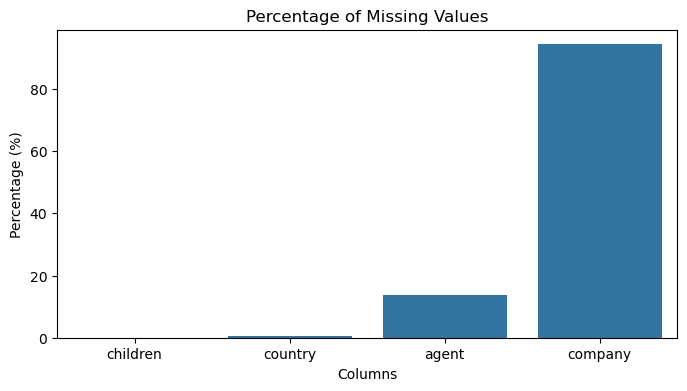

In [34]:
plt.figure(figsize=(8,4))

sns.barplot(
    x=missing_table.index,
    y=missing_table['Percentage (%)']
)

plt.title('Percentage of Missing Values')
plt.ylabel('Percentage (%)')
plt.xlabel('Columns')

plt.show()

### Handling Missing Values in `children`

The `children` column contained only four missing values (0.003% of the dataset).

After inspecting the affected records, it was not possible to reliably determine the number of children for those reservations. Since the proportion of missing values was negligible, the corresponding records were removed from the dataset.

In [52]:
df[df["children"].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,No Deposit,NaN,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,...,No Deposit,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,No Deposit,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,...,No Deposit,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


In [57]:
df = df.dropna(subset=["children"])

df["children"].isnull().sum()

0

### Handling Missing Values in `country`

The `country` column contained 488 missing values, representing approximately 0.41% of the dataset.

Since the proportion of missing values was relatively small and the remaining information in these records was still valuable, the records were retained. Missing country values were replaced with `"Unknown"` to preserve the observations while clearly identifying unavailable country information.

This approach prevents unnecessary data loss and allows the records to remain available for further analysis.

In [64]:
df["country"] = df["country"].fillna("Unknown")

In [66]:
df["agent"].isnull().sum()

16338

In [68]:
df["agent"].nunique()

333

In [70]:
df["agent"].value_counts().head(10)

agent
9.0      31960
240.0    13922
1.0       7191
14.0      3639
7.0       3539
6.0       3290
250.0     2870
241.0     1721
28.0      1666
8.0       1514
Name: count, dtype: int64

In [72]:
df["agent"] = df["agent"].fillna(0)

### Handling Missing Values in `agent`

The `agent` column contained 16,338 missing values, representing approximately 13.69% of the dataset.

Since `agent` is an identifier rather than a numerical measurement, statistical imputation methods such as mean or median replacement are not appropriate.

Missing values were replaced with `0`, indicating that no agent information was available for the corresponding reservation. This approach preserves all observations while maintaining a consistent identifier structure.

In [75]:
df["company"].nunique()

352

In [77]:
df["company"].value_counts().head(10)

company
40.0     927
223.0    784
67.0     267
45.0     250
153.0    215
174.0    149
219.0    141
281.0    138
154.0    133
405.0    119
Name: count, dtype: int64

In [320]:
df["agent"] = df["agent"].fillna(0)

### Handling column `company`

The company column contained more than 94% missing values. Since only a small proportion of reservations were associated with a company and the variable would contribute little analytical value while introducing substantial missing data, the column was removed from the dataset.

In [ ]:
df.drop(columns=["company"], inplace=True)

In [248]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

## 🔄 Duplicate Records Analysis

A total of 32,001 duplicate rows were identified in the dataset.

Several duplicate groups were manually investigated. The analysis revealed that some booking profiles were repeated multiple times, with the most frequent profile appearing 180 times. These repeated observations were found across different booking dates, customer segments, and booking characteristics.

However, because the dataset does not include a unique booking identifier, it is impossible to verify whether these records are true duplicates or legitimate bookings with identical attributes.

For this reason, duplicate records were retained to preserve potentially valid observations and maintain the integrity of the dataset.

In [89]:
df.duplicated().sum()

32001

The dataset was checked for duplicate observations.

A total of 32,001 duplicate rows were identified, suggesting that a substantial number of booking records share identical values across all available variables.

In [91]:
duplicates = df[df.duplicated()]

duplicates.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,0,No Deposit,240.0,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,1,No Deposit,250.0,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,0,No Deposit,250.0,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,0,No Deposit,240.0,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,0,No Deposit,240.0,0,Transient,109.80,0,3,Check-Out,2015-07-08


A sample of duplicated records was displayed to better understand the structure of the duplicate observations.

The preview indicates that multiple bookings share identical values across all recorded attributes.

In [93]:
duplicates.shape

(32001, 31)

The duplicate subset contains 32,001 rows and 31 variables.

In [95]:
df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
).head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40772,City Hotel,0,0,2015,August,32,7,0,2,2,...,0,No Deposit,14.0,0,Transient,75.0,0,1,Check-Out,2015-08-09
40802,City Hotel,0,0,2015,August,32,7,0,2,2,...,0,No Deposit,14.0,0,Transient,75.0,0,1,Check-Out,2015-08-09
40821,City Hotel,0,0,2015,August,32,8,0,1,2,...,0,No Deposit,9.0,0,Transient,89.0,0,1,Check-Out,2015-08-09
40838,City Hotel,0,0,2015,August,32,8,0,1,2,...,0,No Deposit,9.0,0,Transient,89.0,0,1,Check-Out,2015-08-09
76792,City Hotel,0,0,2015,August,33,10,1,0,2,...,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-08-11
76793,City Hotel,0,0,2015,August,33,10,1,0,2,...,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-08-11
76794,City Hotel,0,0,2015,August,33,10,1,0,2,...,0,No Deposit,0.0,0,Transient,75.0,0,0,Check-Out,2015-08-11
41067,City Hotel,0,0,2015,August,33,11,0,1,1,...,0,No Deposit,0.0,0,Transient-Party,88.0,0,0,Check-Out,2015-08-12
41073,City Hotel,0,0,2015,August,33,11,0,1,1,...,0,No Deposit,0.0,0,Transient-Party,88.0,0,0,Check-Out,2015-08-12
41071,City Hotel,0,0,2015,August,33,11,0,1,2,...,0,No Deposit,0.0,0,Transient,80.0,0,0,Check-Out,2015-08-12


Duplicate groups were examined by displaying all observations that belong to duplicate sets.

Several records were found to be identical across every available variable, highlighting the need to determine whether they represent true duplicates or valid bookings with matching characteristics.

In [99]:
duplicates = df[df.duplicated(keep=False)]

duplicates["hotel"].value_counts()

duplicates["market_segment"].value_counts()

duplicates["customer_type"].value_counts()

customer_type
Transient          22215
Transient-Party    16716
Contract            1188
Group                 57
Name: count, dtype: int64

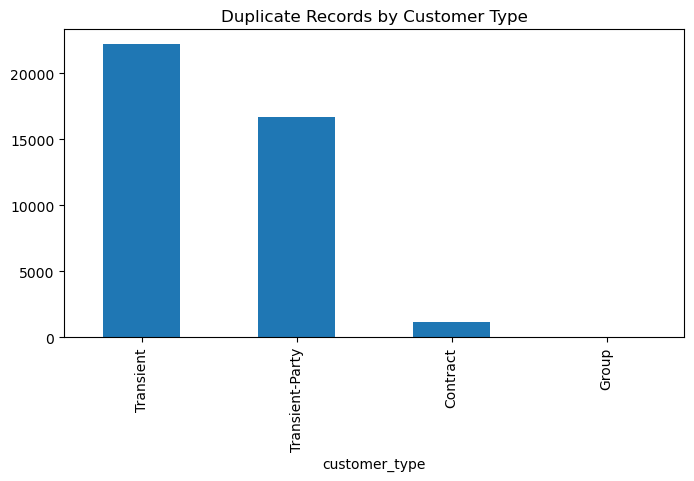

In [326]:
duplicates["customer_type"].value_counts().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Duplicate Records by Customer Type")
plt.show()

The distribution of duplicate records was analyzed across hotel type, market segment, and customer type.

Most duplicate observations were associated with Transient and Transient-Party customers, suggesting that repeated booking patterns are concentrated within these customer groups.

## 🏷️ Data Type Validation

Before proceeding with anomaly detection and further analysis, the data types of all variables were reviewed to ensure that each column is stored in an appropriate format.

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119386 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119386 non-null  object 
 1   is_canceled                     119386 non-null  int64  
 2   lead_time                       119386 non-null  int64  
 3   arrival_date_year               119386 non-null  int64  
 4   arrival_date_month              119386 non-null  object 
 5   arrival_date_week_number        119386 non-null  int64  
 6   arrival_date_day_of_month       119386 non-null  int64  
 7   stays_in_weekend_nights         119386 non-null  int64  
 8   stays_in_week_nights            119386 non-null  int64  
 9   adults                          119386 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119386 non-null  int64  
 12  meal                 

reservation_status_date is a object

In [127]:
df["reservation_status_date"] = pd.to_datetime(
    df["reservation_status_date"]
)

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119386 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   hotel                           119386 non-null  object        
 1   is_canceled                     119386 non-null  int64         
 2   lead_time                       119386 non-null  int64         
 3   arrival_date_year               119386 non-null  int64         
 4   arrival_date_month              119386 non-null  object        
 5   arrival_date_week_number        119386 non-null  int64         
 6   arrival_date_day_of_month       119386 non-null  int64         
 7   stays_in_weekend_nights         119386 non-null  int64         
 8   stays_in_week_nights            119386 non-null  int64         
 9   adults                          119386 non-null  int64         
 10  children                        119386 non-null  float64     

The `reservation_status_date` column was originally stored as an object data type. 

Since this variable represents calendar dates, it was converted to a datetime format to enable date-based operations and analysis.

## 🚨 Anomaly Detection

After handling missing values and investigating duplicate records, the dataset was examined for anomalous or potentially invalid observations.

Several business rules were used to identify records that may represent data quality issues or unrealistic booking scenarios.

### Reservations Without Guests

A total of 180 reservations were identified with zero adults, zero children, and zero babies.

Since a hotel reservation must contain at least one guest, these observations were considered invalid and removed from the dataset.

In [134]:
(df["adults"] == 0).sum()

403



The dataset was checked for records where the number of adults equals zero.

In [139]:
no_guests = df[
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
]

no_guests.shape

(180, 31)

In [141]:
no_guests.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,1,No Deposit,0.0,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,0,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,0,No Deposit,38.0,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,1,No Deposit,308.0,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,1,No Deposit,308.0,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05


In [157]:
df = df[
    ~(
        (df["adults"] == 0) &
        (df["children"] == 0) &
        (df["babies"] == 0)
    )
]

### Negative ADR Values

One observation contained a negative ADR value (-6.38).

Since room rates cannot be negative in a valid hotel booking scenario, this record was removed from the dataset.

In [162]:
(df["adr"] < 0).sum()

1

In [146]:
df[df["adr"] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,2,No Deposit,273.0,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [171]:
df = df[df["adr"] >= 0]

In [148]:
(df["lead_time"] < 0).sum()

0

Lead time values were inspected to verify that booking lead times were non-negative.

### Removal of Zero-Night Reservations

A total of 645 reservations were identified with zero weekday nights, zero weekend nights, and an ADR value of 0.

Since these records do not represent an actual hotel stay and generate no measurable revenue, they were considered non-informative for the objectives of this analysis and were removed from the dataset.

In [152]:
(df["stays_in_weekend_nights"] < 0).sum()

0

In [154]:
(df["stays_in_week_nights"] < 0).sum()

0

In [174]:
(
    (df["stays_in_weekend_nights"] == 0) &
    (df["stays_in_week_nights"] == 0)
).sum()

645

In [176]:
zero_nights = df[
    (df["stays_in_weekend_nights"] == 0) &
    (df["stays_in_week_nights"] == 0)
]

zero_nights.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,3,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,0.0,0,Transient,0.0,0,0,Check-Out,2015-07-01
167,Resort Hotel,0,111,2015,July,28,6,0,0,2,...,0,No Deposit,240.0,0,Transient,0.0,0,2,Check-Out,2015-07-06
168,Resort Hotel,0,0,2015,July,28,6,0,0,1,...,0,No Deposit,250.0,0,Transient,0.0,0,0,Check-Out,2015-07-06
196,Resort Hotel,0,8,2015,July,28,7,0,0,2,...,0,No Deposit,0.0,0,Transient,0.0,0,1,Check-Out,2015-07-07


In [178]:
zero_nights["reservation_status"].value_counts()

reservation_status
Check-Out    622
No-Show       13
Canceled      10
Name: count, dtype: int64

In [180]:
zero_nights["is_canceled"].value_counts()

is_canceled
0    622
1     23
Name: count, dtype: int64

In [182]:
zero_nights["adr"].describe()

count    645.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: adr, dtype: float64

In [184]:
zero_nights["hotel"].value_counts()

hotel
Resort Hotel    381
City Hotel      264
Name: count, dtype: int64

In [186]:
zero_nights["customer_type"].value_counts()

customer_type
Transient          541
Transient-Party     83
Contract            16
Group                5
Name: count, dtype: int64

In [192]:
removed_zero_nights = len(zero_nights)

print(removed_zero_nights)

645


In [199]:
df = df[
    ~(
        (df["stays_in_weekend_nights"] == 0) &
        (df["stays_in_week_nights"] == 0) &
        (df["adr"] == 0)
    )
]

In [201]:
df.shape

(118560, 31)

In [203]:
df.isnull().sum().sum()

0

In [205]:
df.duplicated().sum()

31933

### Duplicate Records

The dataset still contains observations that appear duplicated across all available variables.

However, because no unique booking identifier is provided, it is not possible to determine whether these records are true duplicates or separate reservations that share identical characteristics.

To avoid accidentally removing legitimate bookings, duplicate records were retained in the dataset.

In [211]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
is_canceled,118560.0,0.372571,0.0,0.0,0.0,1.0,1.0,0.483491
lead_time,118560.0,104.508494,0.0,18.0,70.0,161.0,709.0,106.915823
arrival_date_year,118560.0,2016.157667,2015.0,2016.0,2016.0,2017.0,2017.0,0.707692
arrival_date_week_number,118560.0,27.157001,1.0,16.0,28.0,38.0,53.0,13.589513
arrival_date_day_of_month,118560.0,15.8,1.0,8.0,16.0,23.0,31.0,8.782162
stays_in_weekend_nights,118560.0,0.932077,0.0,0.0,1.0,2.0,19.0,0.995431
stays_in_week_nights,118560.0,2.51277,0.0,1.0,2.0,3.0,50.0,1.893242
adults,118560.0,1.859995,0.0,2.0,2.0,2.0,55.0,0.575443
children,118560.0,0.1042,0.0,0.0,0.0,0.0,10.0,0.399127
babies,118560.0,0.007962,0.0,0.0,0.0,0.0,10.0,0.097562


### Extreme ADR Outlier

A single reservation with an ADR of 5,400 was detected.

The next highest ADR in the dataset was 510, indicating an exceptionally large gap between the maximum value and the rest of the observations.

To prevent distortion of descriptive statistics and pricing analyses, this extreme outlier was removed from the dataset.

In [216]:
df.nlargest(10, "adr")[
    ["hotel", "adr", "adults", "children", "babies"]
]

,hotel,adr,adults,children,babies
48515,City Hotel,5400.00,2,0.0,0
111403,City Hotel,510.00,1,0.0,0
15083,Resort Hotel,508.00,2,0.0,0
103912,City Hotel,451.50,2,2.0,0
13142,Resort Hotel,450.00,2,0.0,0
13391,Resort Hotel,437.00,2,2.0,0
39155,Resort Hotel,426.25,2,2.0,0
39568,Resort Hotel,402.00,3,1.0,0
39118,Resort Hotel,397.38,3,2.0,0
13323,Resort Hotel,392.00,2,1.0,0


In [237]:
df[df["adr"] == df["adr"].max()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
48515,City Hotel,1,35,2016,March,13,25,0,1,2,...,1,Non Refund,12.0,0,Transient,5400.0,0,0,Canceled,2016-02-19


In [239]:
df = df[df["adr"] != df["adr"].max()]


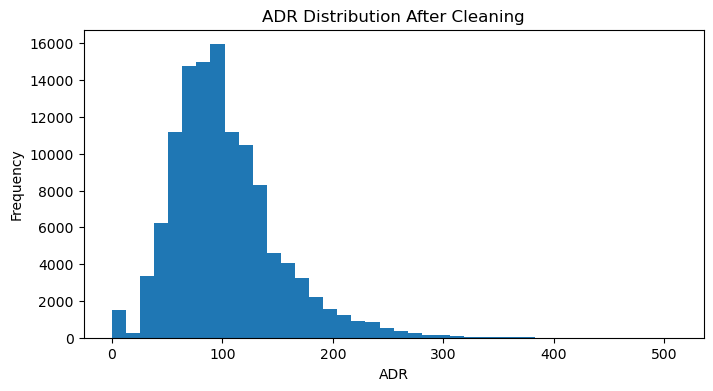

In [337]:
plt.figure(figsize=(8,4))
plt.hist(df["adr"], bins=40)
plt.title("ADR Distribution After Cleaning")
plt.xlabel("ADR")
plt.ylabel("Frequency")
plt.show()

### Large Group Reservations

The largest reservations in the dataset were examined to identify potentially unusual booking patterns.

Only 13 reservations contained more than six adults. Further investigation showed that all of these reservations were ultimately cancelled, resulting in a 100% cancellation rate for this small subset of bookings.

This behavior differs from the overall cancellation patterns observed in the dataset and may indicate that very large group bookings are associated with a higher risk of cancellation.

Since these records appear to be valid observations rather than data quality issues, they were retained in the dataset.

In [243]:
df["adr"].describe()

count    118559.000000
mean        102.482505
std          47.578041
min           0.000000
25%          70.000000
50%          95.000000
75%         126.000000
max         510.000000
Name: adr, dtype: float64

In [279]:
df.nlargest(10, "adults")

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2173,Resort Hotel,1,338,2015,October,41,4,2,0,55,...,0,No Deposit,0.0,0,Group,0.0,0,0,Canceled,2015-01-02
1643,Resort Hotel,1,336,2015,September,37,7,1,2,50,...,0,No Deposit,0.0,0,Group,0.0,0,0,Canceled,2015-01-18
1539,Resort Hotel,1,304,2015,September,36,3,0,3,40,...,0,No Deposit,0.0,0,Group,0.0,0,0,Canceled,2015-01-02
1917,Resort Hotel,1,349,2015,September,39,21,1,3,27,...,0,No Deposit,0.0,0,Group,0.0,0,0,Canceled,2015-01-02
1962,Resort Hotel,1,352,2015,September,39,24,1,3,27,...,0,No Deposit,0.0,0,Group,0.0,0,0,Canceled,2015-01-02
1587,Resort Hotel,1,333,2015,September,36,5,2,5,26,...,0,No Deposit,96.0,0,Group,0.0,0,0,Canceled,2015-01-02
1752,Resort Hotel,1,340,2015,September,37,12,2,5,26,...,0,No Deposit,96.0,0,Group,0.0,0,0,Canceled,2015-01-02
1884,Resort Hotel,1,347,2015,September,38,19,2,5,26,...,0,No Deposit,96.0,0,Group,0.0,0,0,Canceled,2015-01-02
2003,Resort Hotel,1,354,2015,September,39,26,2,5,26,...,0,No Deposit,96.0,0,Group,0.0,0,0,Canceled,2015-01-02
2164,Resort Hotel,1,361,2015,October,40,3,2,5,26,...,0,No Deposit,96.0,0,Group,0.0,0,0,Canceled,2015-01-02


In [267]:
df[df["adults"] > 6]["customer_type"].value_counts()

customer_type
Group    13
Name: count, dtype: int64

In [273]:
df[df["customer_type"] == "Group"]["reservation_status"].value_counts()

reservation_status
Check-Out    511
Canceled      54
No-Show        4
Name: count, dtype: int64

In [275]:
df[df["adults"] > 6].shape[0]

13

In [299]:
(
    df[df["adults"] > 6]["is_canceled"]
    .value_counts(normalize=True) * 100
)

is_canceled
1    100.0
Name: proportion, dtype: float64

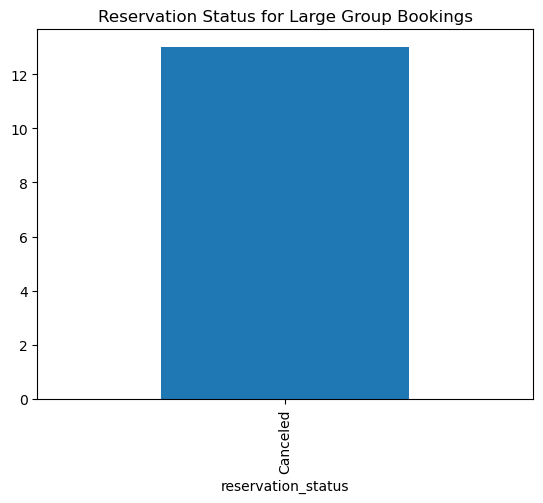

In [318]:
(
    df[df["adults"] > 6]["reservation_status"]
    .value_counts()
    .plot(kind="bar")
)

plt.title("Reservation Status for Large Group Bookings")
plt.show()

### Zero ADR Reservations

A total of 1,165 reservations had an ADR value of zero.

Most of these bookings were associated with the Complementary and Groups market segments, indicating that they likely represent legitimate non-revenue reservations rather than errors in the dataset.

Therefore, these records were retained for general booking analysis. However, they will be excluded from calculations involving average room rates and revenue-related metrics to avoid introducing bias into the results.

In [228]:
(df["adr"] == 0).sum()

1165

In [232]:
df[df["adr"] == 0]["reservation_status"].value_counts()

reservation_status
Check-Out    1000
Canceled      153
No-Show        12
Name: count, dtype: int64

<Axes: xlabel='market_segment'>

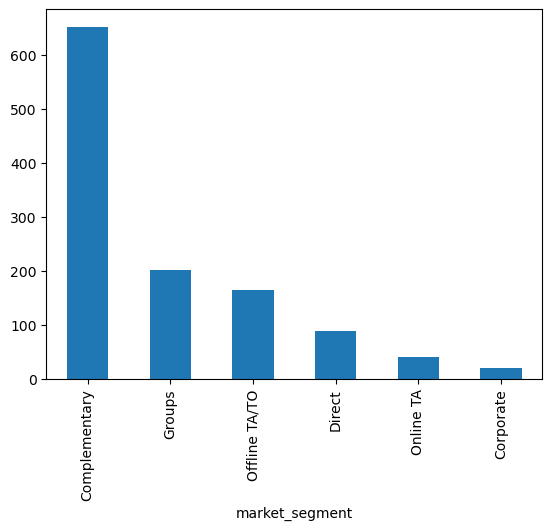

In [297]:
df[df["adr"] == 0]["market_segment"] \
    .value_counts() \
    .head(10) \
    .plot(kind="bar")

## ✅ Data Cleaning Completed

The dataset has been successfully cleaned and prepared for further analysis.

The following preprocessing steps were completed:

- Missing values were handled.
- Data types were validated.
- Duplicate observations were investigated.
- Invalid reservations were removed.
- Extreme outliers were examined.
- Business-specific anomalies were assessed.

The resulting dataset is suitable for exploratory data analysis, visualization, SQL investigation, and predictive modeling.

| Step                            | Result |
| ------------------------------- | -----: |
| Original observations           | 119390 |
| Missing values                  |      0 |
| Company column removed          |      ✓ |
| Children missing removed        |      4 |
| Negative ADR removed            |      1 |
| No guest reservations removed   |    180 |
| Zero-night reservations removed |    645 |
| Extreme ADR removed             |      1 |
| Final observations              | 118559 |


In [339]:
df.shape

(118559, 32)

In [365]:
df["large_group"] = df["large_group"].astype(int)

df.to_csv(
    r"C:\Users\Kompiuteris\Downloads\hotel_bookings_cleaned.csv",
    index=False
)

In [363]:
df["large_group"].value_counts(dropna=False)

large_group
False    118546
True         13
Name: count, dtype: int64

In [367]:
df["large_group"].value_counts()

large_group
0    118546
1        13
Name: count, dtype: int64